In [3]:
import pandas as pd

gigi = pd.read_parquet("/home/renku/work/store/parquet_data/HackDays2026 - GIGI.parquet")

test = pd.read_parquet("/home/renku/work/store/parquet_data/2024/April 2024/LG_AIM2Hackerdays_kWh_20260812_070837.parquet")


# Load lookup tables
mpid_map = pd.read_parquet(
    "../../../store/parquet_data/mpid_zähler_mapping.parquet"
)

zaehler_gp = pd.read_parquet(
    "../../../store/parquet_data/Zähler-GP.parquet"
)

gigi = pd.read_parquet(
    "../../../store/parquet_data/HackDays2026 - GIGI.parquet"
)

# Clean column names
mpid_map.columns = mpid_map.columns.str.strip()
zaehler_gp.columns = zaehler_gp.columns.str.strip()
gigi.columns = gigi.columns.str.strip()

# Normalize IDs
mpid_map["MP ID"] = pd.to_numeric(
    mpid_map["MP ID"], errors="coerce"
).astype("Int64")

zaehler_gp["GPartner"] = pd.to_numeric(
    zaehler_gp["GPartner"], errors="coerce"
).astype("Int64")

gigi["GP-Nr"] = pd.to_numeric(
    gigi["GP-Nr"], errors="coerce"
).astype("Int64")

binary_cols = {
    "WärmePumpe": "has_heatpump",
    "PV": "has_pv",
    "Batterie/Speicher": "has_battery",
    "Ladestation für Elektrofahrzeuge": "has_ev_charger",
    "Wärmepumpenboiler": "has_heatpump_boiler",
}

for source_col, new_col in binary_cols.items():
    cleaned = (
        gigi[source_col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    gigi[new_col] = cleaned.map({
        "x": True,
        "-": False
    })

lookup = (
    mpid_map
    .merge(
        zaehler_gp[["Zählpunktbezeichnung", "GPartner"]],
        on="Zählpunktbezeichnung",
        how="left"
    )
    .merge(
        gigi[
            [
                "GP-Nr",
                "PLZ",
                "Ort",
                "Kanton",
                "has_pv",
                "has_heatpump",
                "has_battery",
                "has_ev_charger",
                "has_heatpump_boiler",
            ]
        ],
        left_on="GPartner",
        right_on="GP-Nr",
        how="left"
    )
)
bool_cols = list(binary_cols.values())
lookup[bool_cols] = lookup[bool_cols].fillna(False)

In [4]:
matched_only = lookup[lookup["GP-Nr"].notna()].copy()

print("Matched rows:", len(matched_only))
print("Matched unique MP IDs:", matched_only["MP ID"].nunique())


Matched rows: 525
Matched unique MP IDs: 413


In [8]:
ev_labels = (
    matched_only[
        ["MP ID", "has_ev_charger"]
    ]
    .dropna(
        subset=[
            "MP ID",
            "has_ev_charger"
        ]
    )
    .copy()
)
ev_labels = (
    ev_labels
    .drop_duplicates(
        subset=["MP ID"]
    )
)

ev_labels["has_ev_charger"] = (
    ev_labels["has_ev_charger"]
    .astype(bool)
)

print(
    ev_labels["has_ev_charger"]
    .value_counts()
)

print()

print(
    ev_labels["has_ev_charger"]
    .value_counts(normalize=True)
)

has_ev_charger
False    363
True      50
Name: count, dtype: int64

has_ev_charger
False    0.878935
True     0.121065
Name: proportion, dtype: float64


In [20]:
from pathlib import Path

data_root = Path(
    "../../../store/parquet_data"
)

time_cols = [
    f"{hour:02d}:{minute:02d}"
    for hour in range(24)
    for minute in [0, 15, 30, 45]
]

files = []

for year in [
    #"2023",
    #"2024",
    "2025",
    "2026",
]:
    files.extend(
        (data_root / year)
        .rglob("*.parquet")
    )

valid_mpids = set(
    ev_labels["MP ID"]
    .dropna()
    .tolist()
)

frames = []

for file in files:

    try:
        df = pd.read_parquet(
            file,
            columns=[
                "MP ID",
                "Datum",
            ] + time_cols
        )

        df["MP ID"] = pd.to_numeric(
            df["MP ID"],
            errors="coerce"
        ).astype("Int64")

        df = df[
            df["MP ID"].isin(
                valid_mpids
            )
        ]

        if not df.empty:
            frames.append(df)

    except Exception as e:
        print(
            "FAILED:",
            file,
            e
        )

if not frames:
    raise ValueError(
        "No EV-labelled time-series data found."
    )

ev_ts = pd.concat(
    frames,
    ignore_index=True
)

print(
    "Rows:",
    len(ev_ts)
)

print(
    "Unique MP IDs:",
    ev_ts["MP ID"].nunique()
)

Rows: 370598
Unique MP IDs: 413


In [21]:
%load_ext autoreload
%autoreload 2

from ev_prediction_suite import (
    extract_ev_features
)

features = extract_ev_features(
    ev_ts
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Found 96 / 96 15-minute columns


/home/renku/work/OSNOVA/dataanalysis/ev_prediction/ev_prediction_suite.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  
/home/renku/work/OSNOVA/dataanalysis/ev_prediction/ev_prediction_suite.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  print(
/home/renku/work/OSNOVA/dataanalysis/ev_prediction/ev_prediction_suite.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(

In [22]:
dataset_ev = (
    features
    .merge(
        ev_labels,
        on="MP ID",
        how="inner"
    )
)

print(
    dataset_ev.shape
)

print()

print(
    dataset_ev["has_ev_charger"]
    .value_counts()
)

(413, 134)

has_ev_charger
False    363
True      50
Name: count, dtype: int64


In [23]:
#data prep

X_ev = dataset_ev.drop(
    columns=[
        "MP ID",
        "has_ev_charger",
    ]
)

y_ev = (
    dataset_ev["has_ev_charger"]
    .astype(int)
)

X_ev = X_ev.replace(
    [np.inf, -np.inf],
    np.nan
)

X_ev = X_ev.drop(
    columns=["number_of_days"]
)

In [24]:
from sklearn.model_selection import (
    train_test_split
)

from sklearn.pipeline import Pipeline

from sklearn.impute import (
    SimpleImputer
)

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
)


X_train_ev, X_test_ev, y_train_ev, y_test_ev = (
    train_test_split(
        X_ev,
        y_ev,
        test_size=0.25,
        random_state=42,
        stratify=y_ev,
    )
)



In [25]:
ev_model = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=750,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )
    ),
])


ev_model.fit(
    X_train_ev,
    y_train_ev
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](131,)","['overall_mean','overall_std','mean_daily_std',...,'profile_23_15', 'profile_23_30','profile_23_45']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,131
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missi

In [26]:
ev_pred = ev_model.predict(
    X_test_ev
)

ev_prob = ev_model.predict_proba(
    X_test_ev
)[:, 1]


print(
    classification_report(
        y_test_ev,
        ev_pred,
        target_names=[
            "No EV charger",
            "EV charger",
        ]
    )
)

print(
    confusion_matrix(
        y_test_ev,
        ev_pred
    )
)

print(
    "ROC AUC:",
    roc_auc_score(
        y_test_ev,
        ev_prob
    )
)

               precision    recall  f1-score   support

No EV charger       0.89      0.89      0.89        91
   EV charger       0.23      0.23      0.23        13

     accuracy                           0.81       104
    macro avg       0.56      0.56      0.56       104
 weighted avg       0.81      0.81      0.81       104

[[81 10]
 [10  3]]
ROC AUC: 0.621301775147929


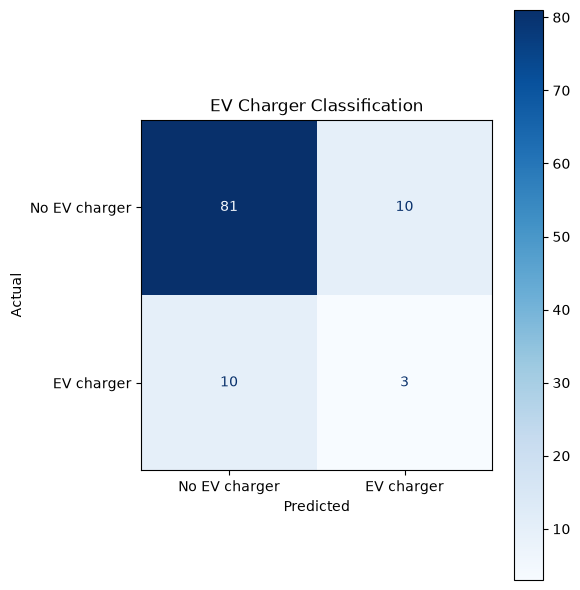

In [27]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay
)

fig, ax = plt.subplots(
    figsize=(6, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_test_ev,
    ev_pred,
    display_labels=[
        "No EV charger",
        "EV charger",
    ],
    cmap="Blues",
    values_format="d",
    ax=ax,
)

ax.set_title(
    "EV Charger Classification"
)

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "Actual"
)

plt.tight_layout()
plt.show()

In [28]:
from pathlib import Path
import joblib
import json


model_dir = Path("ev_model")
model_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Save the complete sklearn pipeline
joblib.dump(
    ev_model,
    model_dir / "ev_model.joblib"
)

# Save the exact feature schema used during training
with open(
    model_dir / "ev_feature_columns.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        X_ev.columns.tolist(),
        f,
        ensure_ascii=False,
        indent=2
    )

print("EV model exported successfully")
print("Model:", model_dir / "ev_model.joblib")
print("Features:", model_dir / "ev_feature_columns.json")

EV model exported successfully
Model: ev_model/ev_model.joblib
Features: ev_model/ev_feature_columns.json
